# Wikispeedia Navigation Paths

https://snap.stanford.edu/data/wikispeedia.html

"This dataset contains human navigation paths on Wikipedia, collected through the human-computation game Wikispeedia. In Wikispeedia, users are asked to navigate from a given source to a given target article, by only clicking Wikipedia links. A condensed version of Wikipedia (4,604 articles) is used. In addition to the navigation paths, we provide the full HTML package of this version of Wikipedia, as well as all articles in plaintext."

Rating is from 1 ("easy") to 5 ("brutal")


## 1. Imports and load data

In [291]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np  
import pandas as pd 
import plotly.graph_objs as go
import seaborn as sns
import warnings
import urllib.parse


from scipy import stats

from flow_tree_utils import generate_trajs_from_df, load_test_df, OBJECTS, generate_flow_tree_from_trajs, plot_flow_tree


In [307]:
data_path = "data/wikispeedia_paths-and-graph"

# load article names
article_names = []
with open(f"{data_path}/articles.tsv") as f:
    for line in f:
        line = line.strip()
        if len(line) == 0 or line[0] == "#": continue

        # decoded_line = urllib.parse.unquote(line)
        # maybe leave in URL encoding bc the 
        article_names.append(line)

# load shortest paths
def get_nth_category(category_string, n):
    category_list = category_string.split(".")
    if len(category_list) <= n:
        return pd.NA
    return category_list[n]

# load categories
column_names = ["article", "category"]
categories_df = pd.read_csv(f"{data_path}/categories.tsv", names=column_names, sep='\t', skiprows=[i for i in range(13)])
categories_df["num_categories"] = categories_df["category"].apply(lambda x: len(x.split(".")))
print("Max category depth is", categories_df["num_categories"].max())
for i in range(categories_df["num_categories"].max()):
    categories_df[f"category{i}"] = categories_df["category"].apply(lambda x: get_nth_category(x, i))
categories_df


Max category depth is 4


,article,category,num_categories,category0,category1,category2,category3
0,%C3%81ed%C3%A1n_mac_Gabr%C3%A1in,subject.History.British_History.British_Histor...,4,subject,History,British_History,British_History_1500_and_before_including_Roma...
1,%C3%81ed%C3%A1n_mac_Gabr%C3%A1in,subject.People.Historical_figures,3,subject,People,Historical_figures,<NA>
2,%C3%85land,subject.Countries,2,subject,Countries,<NA>,<NA>
3,%C3%85land,subject.Geography.European_Geography.European_...,4,subject,Geography,European_Geography,European_Countries
4,%C3%89douard_Manet,subject.People.Artists,3,subject,People,Artists,<NA>
...,...,...,...,...,...,...,...
5199,Zirconium,subject.Science.Chemistry.Chemical_elements,4,subject,Science,Chemistry,Chemical_elements
5200,Zoroaster,subject.People.Religious_figures_and_leaders,3,subject,People,Religious_figures_and_leaders,<NA>
5201,Zuid-Gelders,subject.Geography.European_Geography,3,subject,Geography,European_Geography,<NA>
5202,Zuid-Gelders,subject.Language_and_literature.Languages,3,subject,Language_and_literature,Languages,<NA>


In [309]:
for i in range(categories_df["num_categories"].max()):
    print(categories_df.value_counts(f"category{i}"))

category0
subject    5204
Name: count, dtype: int64
category1
Science                    1122
Geography                  1084
People                      689
History                     545
Everyday_life               374
Design_and_Technology       254
Countries                   229
Citizenship                 224
Language_and_literature     196
Religion                    134
Music                        97
Business_Studies             88
IT                           85
Mathematics                  45
Art                          38
Name: count, dtype: int64
category2
Biology                                  704
Physics                                  226
Chemistry                                192
British_History                          158
European_Geography                       139
                                        ... 
Computing_People                           9
Chemists                                   8
Antarctica                                 8
Producers_directo

In [347]:
category_graph = nx.Graph() 
max_category_depth = categories_df["num_categories"].max()
for i in range(max_category_depth):
    category_graph.add_nodes_from(categories_df[f"category{i}"].dropna(), layer=i)

edges = []
for _, row in categories_df.iterrows():
    for i in range(max_category_depth-1):
        if pd.isna(row[f"category{i}"]) or pd.isna(row[f"category{i+1}"]):
            break
        edges.append([row[f"category{i}"], row[f"category{i+1}"]])
category_graph.add_edges_from(edges)
nx.info(category_graph)

/var/folders/24/lp6939qs6f1d149198s_3mv40000gn/T/ipykernel_37478/1574171976.py:13: DeprecationWarning: info is deprecated and will be removed in version 3.0.

  nx.info(category_graph)


'Graph with 142 nodes and 145 edges'

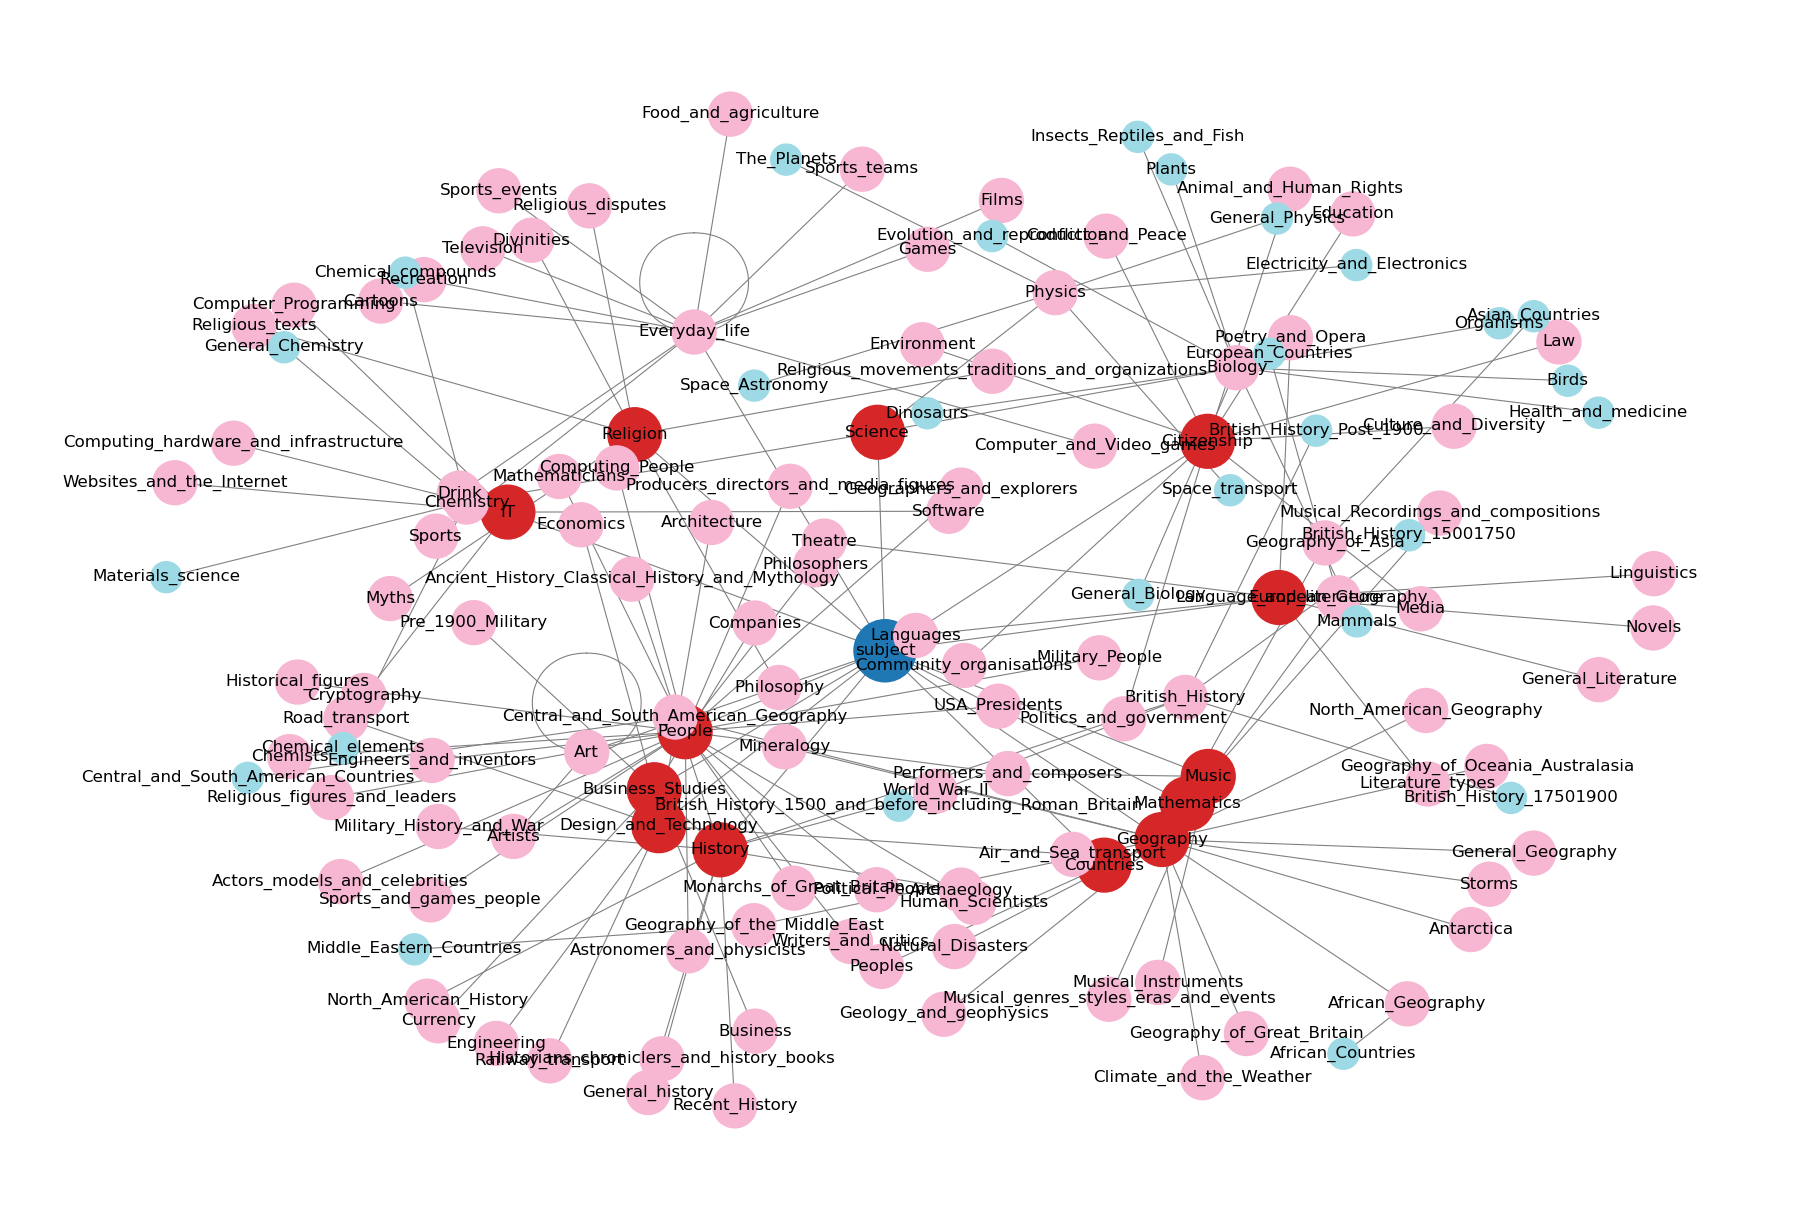

In [338]:
from networkx.drawing.nx_agraph import graphviz_layout
import matplotlib.pyplot as plt

# pos = nx.drawing.nx_agraph.graphviz_layout(category_graph, prog="dot")  # tree layout
pos = nx.spring_layout(category_graph, k=0.7, iterations=100)  # spread nodes out

layers = nx.get_node_attributes(category_graph, "layer")
node_colors = [layers[node] for node in category_graph.nodes()]
node_sizes = [2000-500*layers[node] for node in category_graph.nodes()]

plt.figure(figsize=(18, 12))  # make the figure larger
nx.draw(
    category_graph, pos,
    with_labels=True,
    node_size=node_sizes,            # bigger nodes
    node_color=node_colors,
    cmap=plt.cm.tab20,   # try 'plasma', 'tab20' for alternatives
    font_size=12,             # larger labels
    font_color='black',
    edge_color="gray",
    width=0.8,
)
plt.axis("off")
plt.show()

### Visualise graph

In [340]:
# load links
column_names = ["linkSource", "linkTarget"]
edges_df = pd.read_csv(f"{data_path}/links.tsv", names=column_names, sep='\t', skiprows=[i for i in range(13)])
edge_dict = dict(zip(edges_df.linkSource, edges_df.linkTarget))

In [352]:
category_level_dict = {}
for i in range(max_category_depth):
    for cat in categories_df[f"category{i}"].dropna():
        category_level_dict[cat] = i

for _, row in categories_df.iterrows():
    category_level_dict[row["article"]] = row["num_categories"]


print(category_level_dict)

edge_level_dict = {}
for k, v in edge_dict.items():
    if k not in category_level_dict or v not in category_level_dict:
        continue
    edge_level_dict[(k, v)] = category_level_dict[v] - category_level_dict[k]

edge_level_dict

{'subject': 0, 'History': 3, 'People': 1, 'Countries': 1, 'Geography': 3, 'Business_Studies': 1, 'Science': 3, 'Everyday_life': 2, 'Design_and_Technology': 1, 'Music': 3, 'IT': 1, 'Language_and_literature': 1, 'Mathematics': 2, 'Religion': 3, 'Art': 3, 'Citizenship': 3, 'British_History': 2, 'Historical_figures': 2, 'European_Geography': 2, 'Artists': 2, 'Currency': 3, 'General_history': 2, 'Military_History_and_War': 2, 'Physics': 4, 'Sports_events': 2, 'Storms': 2, 'Recent_History': 2, 'Geology_and_geophysics': 2, 'Natural_Disasters': 2, 'Railway_transport': 2, 'Sports_and_games_people': 2, 'Biology': 4, 'Performers_and_composers': 2, 'Computing_hardware_and_infrastructure': 2, 'Companies': 2, 'Novels': 2, 'Musical_genres_styles_eras_and_events': 2, 'Geography_of_the_Middle_East': 2, 'Ancient_History_Classical_History_and_Mythology': 2, 'Religious_movements_traditions_and_organizations': 2, 'Theatre': 3, 'Geographers_and_explorers': 2, 'Geography_of_Great_Britain': 2, 'Religious_text

{('%C3%81ed%C3%A1n_mac_Gabr%C3%A1in', 'Wales'): 0,
 ('%C3%85land', 'World_War_II'): 0,
 ('%C3%89douard_Manet', 'Washington%2C_D.C.'): 0,
 ('%C3%89ire', 'United_Kingdom'): -1,
 ('%C3%93engus_I_of_the_Picts', 'York'): 0,
 ('%E2%82%AC2_commemorative_coins', 'Zeus'): 0,
 ('10th_century', 'Viking'): 0,
 ('11th_century', 'William_I_of_England'): 0,
 ('12th_century', 'Time'): 1,
 ('13th_century', 'Time'): 1,
 ('14th_century', 'Washington%2C_D.C.'): 0,
 ('15th_Marine_Expeditionary_Unit', 'World_War_II'): 1,
 ('15th_century', 'Zheng_He'): 0,
 ('16_Cygni', 'Sun'): 0,
 ('16_Cygni_Bb', 'Water'): -1,
 ('16th_century', 'William_the_Silent'): 0,
 ('1755_Lisbon_earthquake', 'Voltaire'): 0,
 ('17th_century', 'William_Shakespeare'): 0,
 ('1896_Summer_Olympics', 'United_States'): 0,
 ('18th_century', 'Wolfgang_Amadeus_Mozart'): 0,
 ('1928_Okeechobee_Hurricane', 'United_States_Virgin_Islands'): 0,
 ('1973_oil_crisis', 'Yom_Kippur_War'): 0,
 ('1980_eruption_of_Mount_St._Helens', 'Yellowstone_National_Park'

In [294]:
G = nx.DiGraph() 

G.add_nodes_from(edges_df["linkSource"])
G.add_nodes_from(edges_df["linkTarget"])

edges = [(row["linkSource"], row["linkTarget"]) for _, row in edges_df.iterrows()]
G.add_edges_from(edges)

In [296]:
nx.info(G)

/var/folders/24/lp6939qs6f1d149198s_3mv40000gn/T/ipykernel_37478/1064119803.py:1: DeprecationWarning: info is deprecated and will be removed in version 3.0.

  nx.info(G)


'DiGraph with 4592 nodes and 119881 edges'

In [297]:
communities = list(nx.algorithms.community.greedy_modularity_communities(G))
print(communities)
# Assign cluster IDs as node attributes
community_map = {}
for i, comm in enumerate(communities):
    for node in comm:
        community_map[node] = i

nx.set_node_attributes(G, community_map, "community")

[frozenset({'Epic_of_Gilgamesh', 'Domesticated_turkey', 'Corn_oil', 'Fetal_alcohol_spectrum_disorder', 'Skylark', 'Rosemary', 'Lens_%28anatomy%29', 'Europium', 'Keurusselk%C3%A4', 'Gray_Wolf', 'Sand_shark', 'Mars_Reconnaissance_Orbiter', 'Definition_of_planet', 'African_Penguin', 'Clay', 'Crossbill', 'Mendelevium', 'Greek_mythology', 'Ice_age', 'Achilles_tendon', 'Virus', 'Mars_Exploration_Rover', 'Meat', 'Gadolinium', 'Goose', 'Cassowary', 'Fugu', 'North_America', 'Gazelle', 'Formic_acid', 'Gallium', 'Pea', 'Optical_telescope', 'Pi', 'Perfect_number', 'Sodium_sulfate', 'Ganges_shark', 'Elias_Ashmole', 'Comet_Shoemaker-Levy_9', 'Rio_Tinto_Group', 'Bohor_Reedbuck', 'Bean', 'Biodiversity', 'Animal_rights', 'Ant', 'Distilled_beverage', 'Ceres_%28dwarf_planet%29', 'Common_Eland', 'Gorilla', 'Long_pepper', 'Kuru_%28disease%29', 'Weight_training', 'Venus', 'Mind', 'Eliminative_materialism', 'Tree_frog', 'Redshift', 'Ancient_Rome', 'Garden', 'Arugula', 'Blaise_Pascal', 'Bertrand_Russell', 'Ty

In [298]:
print(len(communities))

12


In [341]:
from pyvis.network import Network
import random

def sample_nodes(G, fraction=0.1, seed=None):
    random.seed(seed)
    num_nodes = int(len(G) * fraction)
    sampled_nodes = random.sample(sorted(G.nodes()), num_nodes)
    return G.subgraph(sampled_nodes).copy()

G_sub = sample_nodes(G, fraction=0.1, seed=42)
print(nx.info(G_sub))

net = Network(notebook=True, height="750px", width="100%", bgcolor="#222222", font_color="white")

for node, data in G_sub.nodes(data=True):
    net.add_node(node, label=str(node), group=data.get("community", 0))

for u, v in G_sub.edges():
    net.add_edge(u, v)

# net.show("wikispeedia_network.html")

TypeError: boolean value of NA is ambiguous

In [369]:
def get_nth_article(article_string, n):
    article_list = article_string.split(";")
    return article_list[n]

def get_path_len(x):
    return len(x.split(";"))

def get_least_common_level(art1, art2):
    art1_row = categories_df[categories_df["article"]==art1]
    art2_row = categories_df[categories_df["article"]==art2]

    if len(art1_row) == 0 or len(art2_row) == 0: return None
    
    lcl = None
    for i in range(max_category_depth):
        art1_cat = art1_row[f"category{i}"].iloc[0]
        art2_cat = art2_row[f"category{i}"].iloc[0] # sometimes there are two categories got to fix

        if pd.isna(art1_cat) or pd.isna(art2_cat) or art1_cat != art2_cat:
            return lcl
        else:
            lcl = i
    return lcl

    # for i in range([f"category{i}"]
def get_levels_traj(x):
    articles = x.split(";")
    traj = []
    for i, article in enumerate(articles):
        if article == "<":
            # this means back click!
            for j in range(i-1, 0, -1):
                # sometimes more than one in a row
                if articles[j] != "<":
                    traj.append(category_level_dict.get(articles[j], None))
                    break
        else:
            traj.append(category_level_dict.get(article, None))
    return traj

def get_level_hops(x):
    articles = x.split(";")
    traj = []
    for i, article in enumerate(articles):
        if article == "<":
            # this means back click!
            for j in range(i-1, 0, -1):
                # sometimes more than one in a row
                if articles[j] != "<":
                    traj.append(articles[j])
                    break
        else:
            traj.append(article)

    lcls = []
    for i in range(len(traj)-1):
        a, b = traj[i], traj[i+1]
        lcls.append(get_least_common_level(a, b))
    return lcls


# load successful trajectories
column_names = ["hashedIpAddress", "timestamp", "durationInSec", "path", "rating"]
finished_trajs_df = pd.read_csv(f"{data_path}/paths_finished.tsv", names=column_names, sep='\t', skiprows=[i for i in range(16)])
finished_trajs_df["StartAt"] = finished_trajs_df["path"].apply(lambda x: get_nth_article(x, 0))
finished_trajs_df["EndAt"] = finished_trajs_df["path"].apply(lambda x: get_nth_article(x, -1))
finished_trajs_df["finished"] = True

# load unsuccessful trajectories
column_names = ["hashedIpAddress", "timestamp", "durationInSec", "path", "target", "type"]
unfinished_trajs_df = pd.read_csv(f"{data_path}/paths_unfinished.tsv", names=column_names, sep='\t', skiprows=[i for i in range(17)])
unfinished_trajs_df["StartAt"] = unfinished_trajs_df["path"].apply(lambda x: get_nth_article(x, 0))
unfinished_trajs_df["EndAt"] = unfinished_trajs_df["target"]
unfinished_trajs_df["finished"] = False

trajs_df = pd.concat([finished_trajs_df, unfinished_trajs_df])
trajs_df.reset_index()
trajs_df["traj_len"] = trajs_df["path"].apply(get_path_len)
trajs_df["levels_traj"] = trajs_df["path"].apply(get_levels_traj)
trajs_df["level_hops"] = trajs_df["path"].apply(get_level_hops)


trajs_df


,hashedIpAddress,timestamp,durationInSec,path,rating,StartAt,EndAt,finished,target,type,traj_len,levels_traj,level_hops
0,6a3701d319fc3754,1297740409,166,14th_century;15th_century;16th_century;Pacific...,NaN,14th_century,African_slave_trade,True,NaN,NaN,9,"[3, 3, 3, 3, 3, 3, 3, 4, 3]","[2, 2, 0, 2, 1, 2, 0, 1]"
1,3824310e536af032,1344753412,88,14th_century;Europe;Africa;Atlantic_slave_trad...,3.0,14th_century,African_slave_trade,True,NaN,NaN,5,"[3, 3, 3, 4, 3]","[0, 1, 0, 1]"
2,415612e93584d30e,1349298640,138,14th_century;Niger;Nigeria;British_Empire;Slav...,NaN,14th_century,African_slave_trade,True,NaN,NaN,8,"[3, 2, 2, 3, 3, 3, 4, 3]","[0, 3, 0, 0, 0, 0, 1]"
3,64dd5cd342e3780c,1265613925,37,14th_century;Renaissance;Ancient_Greece;Greece,NaN,14th_century,Greece,True,NaN,NaN,4,"[3, 3, 3, 4]","[2, 1, 0]"
4,015245d773376aab,1366730828,175,14th_century;Italy;Roman_Catholic_Church;HIV;R...,3.0,14th_century,John_F._Kennedy,True,NaN,NaN,7,"[3, 4, 3, 4, 3, 3, 3]","[0, 0, 0, 0, 0, 0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
24870,109ed71f571d86e9,1389787605,180,Franz_Kafka;Tuberculosis;World_Health_Organiza...,NaN,Franz_Kafka,Cholera,False,Cholera,restart,8,"[3, 4, 3, 4, 2, 2, 3, 2]","[0, 0, 0, 0, 3, 1, 2]"
24871,232f992e57d43e8d,1389787697,6,Modern_history,NaN,Modern_history,Hollandic,False,Hollandic,restart,1,[3],[]
24872,2e09a7224600a7cd,1389798400,1900,Computer_programming;Linguistics;Culture;Popul...,NaN,Computer_programming,The_Beatles,False,The_Beatles,timeout,5,"[3, 3, 3, 3, 3]","[0, 0, 0, 2]"
24873,60af9e2138051b96,1389799481,1903,Jamaica;United_Kingdom;World_War_II;Battle_of_...,NaN,Jamaica,Alan_Turing,False,Alan_Turing,timeout,4,"[2, 3, 4, 3]","[0, 0, 1]"


## Prelim data analysis

In [262]:
def make_distribution_plot(data, jitter_high=0.3, y_start=0, x_label="", x_ticks=np.arange(0, 1.1, 0.5), log_scale=False, figsize=(8, 8)):
    fig, ax = plt.subplots(figsize=figsize)

    COLORS = ["#FF5A5F", "#FFB400", "#007A87"]

    # Half-violin plot as above
    # pt.half_violinplot(
    #     x=subj_mean_accs, #y="species", 
    #     palette=COLORS, 
    #     inner=None,  width=1, ax=ax
    # )
    sns.kdeplot(data, color = 'darkblue', log_scale=log_scale, linewidth=4, ax=ax)

    # Jitter the values on the vertical axis
    y = y_start + np.random.uniform(high=ax.get_ylim()[1]*jitter_high, size=len(data))

    # Add the rain using the scatter method.
    ax.scatter(data, y, color=COLORS[0], alpha=0.005, s=5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_linewidth(2.5)
    ax.yaxis.set_visible(False)

    ax.tick_params(axis='both', which='major', labelsize=15, width=2, length=10)
    plt.xticks(x_ticks)
    plt.xlabel(x_label, fontsize=15)
    plt.xlim(0,x_ticks[-1])
    plt.show()

Finished trajectory lengths


/var/folders/24/lp6939qs6f1d149198s_3mv40000gn/T/ipykernel_37478/3624016575.py:28: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0,x_ticks[-1])


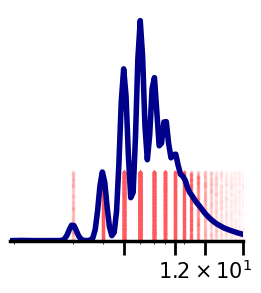

Uninished trajectory lengths


/var/folders/24/lp6939qs6f1d149198s_3mv40000gn/T/ipykernel_37478/3624016575.py:28: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0,x_ticks[-1])


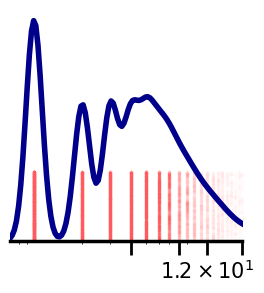

In [264]:
to_plot = [trajs_df[trajs_df["finished"]]["traj_len"], trajs_df[~trajs_df["finished"]]["traj_len"]]
# plt.hist(to_plot, bins=20, range=[1,20], color=["cornflowerblue", "pink"], histtype='stepfilled', density=True, alpha=0.4, label=['finished', 'unfinished'])
# plt.legend()
# plt.title("Trajectory lengths")
# plt.show()

print("Finished trajectory lengths")
make_distribution_plot(trajs_df[trajs_df["finished"]]["traj_len"], x_label="", x_ticks=[0, 4, 8, 12, 20], log_scale=True, figsize=(3,3))

print("Uninished trajectory lengths")
make_distribution_plot(trajs_df[~trajs_df["finished"]]["traj_len"], x_label="", x_ticks=[0, 4, 8, 12, 20], log_scale=True, figsize=(3,3))

hashedIpAddress
0d57c8c57d75e2f5    4865
473d6ac602c2b198     545
7d5624e35c9523ef     292
5bb5836b425e6bfe     243
6b039e9953cf075e     231
                    ... 
511d95552bc90176       1
511b637959419eb1       1
511b413b524c8430       1
2339b994349c63c6       1
000386124f307de8       1
Name: count, Length: 14244, dtype: int64


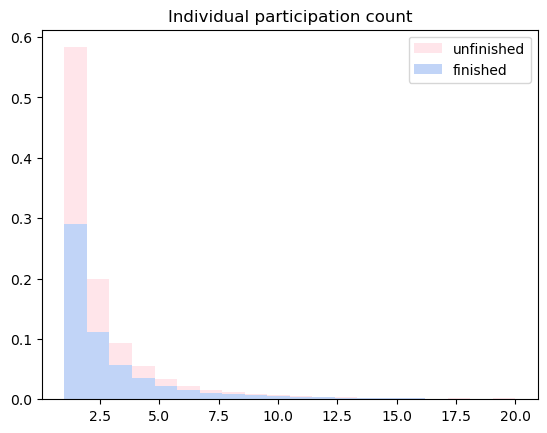

Games finished by IP


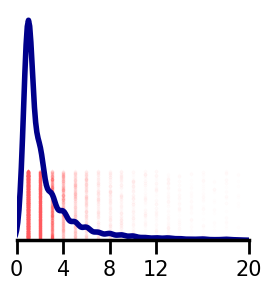

Games unfinished by IP


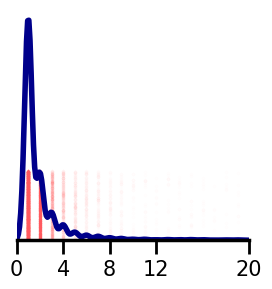

In [271]:
unique_indivs_fin = trajs_df[trajs_df["finished"]].value_counts("hashedIpAddress")
unique_indivs_unfin = trajs_df[~trajs_df["finished"]].value_counts("hashedIpAddress")

print(unique_indivs_fin)
# print(unique_indivs_unfin)
# print(sum([1 if x == 1 else 0 for x in unique_indivs]))
to_plot = [unique_indivs_fin, unique_indivs_unfin]
plt.hist(to_plot, bins=20, range=[1,20], color=["cornflowerblue", "pink"], stacked=True, histtype='stepfilled', density=True, alpha=0.4, label=['finished', 'unfinished'])

plt.legend()
plt.title("Individual participation count")
plt.show()


print("Games finished by IP")
make_distribution_plot(unique_indivs_fin[unique_indivs_fin < 20], x_label="", x_ticks=[0, 4, 8, 12, 20], figsize=(3,3))

print("Games unfinished by IP")
make_distribution_plot(unique_indivs_unfin[unique_indivs_unfin < 20], x_label="", x_ticks=[0, 4, 8, 12, 20], figsize=(3,3))

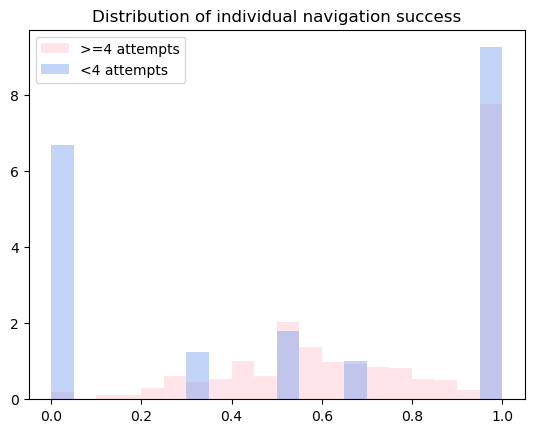

Game success rates <4 attempts


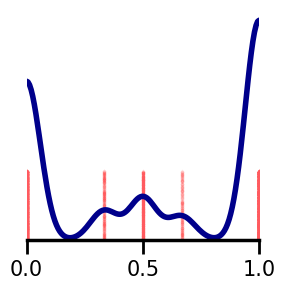

Game success rates >=4 attempts


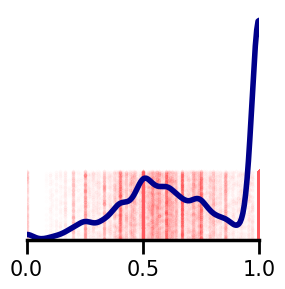

Game success rates ignoring perfect people and helpless failures


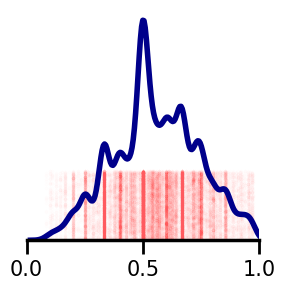

In [275]:
trajs_df["subj_attempts"] = trajs_df.groupby("hashedIpAddress")["path"].transform("count")
trajs_df["subj_mean_acc"] = trajs_df.groupby("hashedIpAddress")["finished"].transform("mean")

k = 4
to_plot = [trajs_df[trajs_df["subj_attempts"] < k]["subj_mean_acc"], trajs_df[trajs_df["subj_attempts"] >= k]["subj_mean_acc"]]
plt.hist(to_plot, bins=20, range=[0,1], color=["cornflowerblue", "pink"], stacked=False, histtype='stepfilled', density=True, alpha=0.4, label=[f"<{k} attempts", f">={k} attempts"])
plt.legend()
plt.title("Distribution of individual navigation success")
plt.show()

print(f"Game success rates <{k} attempts")
make_distribution_plot(trajs_df[trajs_df["subj_attempts"] < k]["subj_mean_acc"], x_label="", x_ticks=[0, 0.5, 1], figsize=(3,3))

print(f"Game success rates >={k} attempts")
make_distribution_plot(trajs_df[trajs_df["subj_attempts"] >= k]["subj_mean_acc"], x_label="", x_ticks=[0, 0.5, 1], figsize=(3,3))


print(f"Game success rates ignoring perfect people and helpless failures")
make_distribution_plot(trajs_df[(trajs_df["subj_mean_acc"] < 1) & (trajs_df["subj_mean_acc"] > 0)]["subj_mean_acc"], x_label="", x_ticks=[0, 0.5, 1], figsize=(3,3))

In [ ]:
# look at most common paths

# irreversibility, start vs end
# jump into flow tree stuff

# identify subset with enough attempts on a given paths
# first find if therer is something about difficulty or path length

Accuracy by start


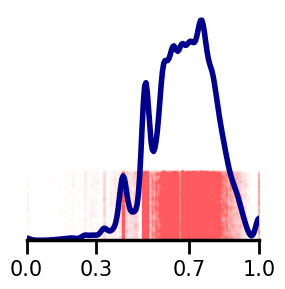

Accuracy by end


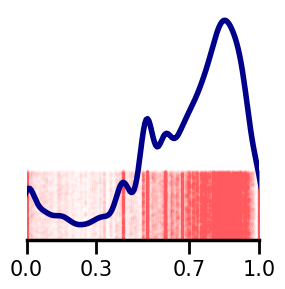

Accuracy by path


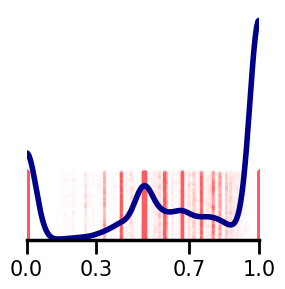

In [276]:
trajs_df["acc_by_start"] = trajs_df.groupby("StartAt")["finished"].transform("mean")
trajs_df["acc_by_end"] = trajs_df.groupby("EndAt")["finished"].transform("mean")
trajs_df["acc_by_path"] = trajs_df.groupby(["StartAt", "EndAt"])["finished"].transform("mean")


print("Accuracy by start")
make_distribution_plot(trajs_df["acc_by_start"], x_label="", x_ticks=[0, 0.3, 0.7, 1.0], figsize=(3,3)) #Navigator Accuracy

print("Accuracy by end")
make_distribution_plot(trajs_df["acc_by_end"], x_label="", x_ticks=[0, 0.3, 0.7, 1.0], figsize=(3,3)) #Navigator Accuracy

print("Accuracy by path")
make_distribution_plot(trajs_df["acc_by_path"], x_label="", x_ticks=[0, 0.3, 0.7, 1.0], figsize=(3,3)) #Navigator Accuracy

## 2. Process trajectories

In [372]:
# nodes need to be strings apparently
article_to_index = {article: str(i) for i, article in enumerate(article_names)}
index_to_article = {str(i): article for i, article in enumerate(article_names)}

def decode_path_to_traj(path):
    traj = []
    articles = path.split(";")
    for i, article in enumerate(articles):
        if article == "<":
            # this means back click!
            for j in range(i-1, 0, -1):
                # sometimes more than one in a row
                if articles[j] != "<":
                    traj.append(article_to_index[articles[j]])
                    break
        else:
            traj.append(article_to_index[article])
    return traj

finished_trajs_df["traj"] = finished_trajs_df["path"].apply(decode_path_to_traj) 
finished_trajs_df["StartAt"] = finished_trajs_df["traj"].apply(lambda x: x[0]) 
finished_trajs_df["EndAt"] = finished_trajs_df["traj"].apply(lambda x: x[-1]) 
finished_trajs_df["StartEnd"] = finished_trajs_df["StartAt"] + "_" + finished_trajs_df["EndAt"]

finished_trajs_df["avg_rating"] = finished_trajs_df.groupby("StartEnd")["rating"].transform("mean")

finished_trajs_df[["StartEnd", "traj", "avg_rating"]]


,StartEnd,traj,avg_rating
0,10_143,"[10, 12, 15, 3134, 377, 105, 128, 379, 143]",3.0
1,10_143,"[10, 1433, 128, 379, 143]",3.0
2,10_143,"[10, 2982, 2984, 694, 3755, 128, 379, 143]",3.0
3,10_1793,"[10, 3464, 241, 1793]",NaN
4,10_2266,"[10, 2183, 3529, 1836, 3542, 3342, 2266]",3.0
...,...,...,...
51313,4558_928,"[4558, 240, 928]",NaN
51314,4558_1500,"[4558, 1547, 706, 706, 24, 857, 72, 3026, 1500]",3.0
51315,4558_4273,"[4558, 393, 1385, 1568, 4297, 4022, 4273]",NaN
51316,4562_97,"[4562, 393, 4297, 97]",1.0


In [373]:
finished_trajs_df.groupby("StartEnd")["path"].transform("count")


0        3
1        3
2        3
3        1
4        2
        ..
51313    1
51314    1
51315    1
51316    1
51317    1
Name: path, Length: 51318, dtype: int64

In [ ]:
## Just focus on the top 50 most common paths

In [378]:
# find most common tasks
k = 100
most_common_paths = finished_trajs_df["StartEnd"].value_counts()[:k].index.tolist()
print(most_common_paths[-1])
len(finished_trajs_df[finished_trajs_df["StartEnd"] == most_common_paths[-1]]["traj"])

1866_2317


12

In [94]:
# find most common tasks
k = 100
most_common_paths = finished_trajs_df["hashedIpAddress"].value_counts()[:k].index.tolist()
print(most_common_paths[-1])
len(finished_trajs_df[finished_trajs_df["hashedIpAddress"] == most_common_paths[-1]]["traj"])

3cc73ae144f4f570


30

## Flow Tree analysis

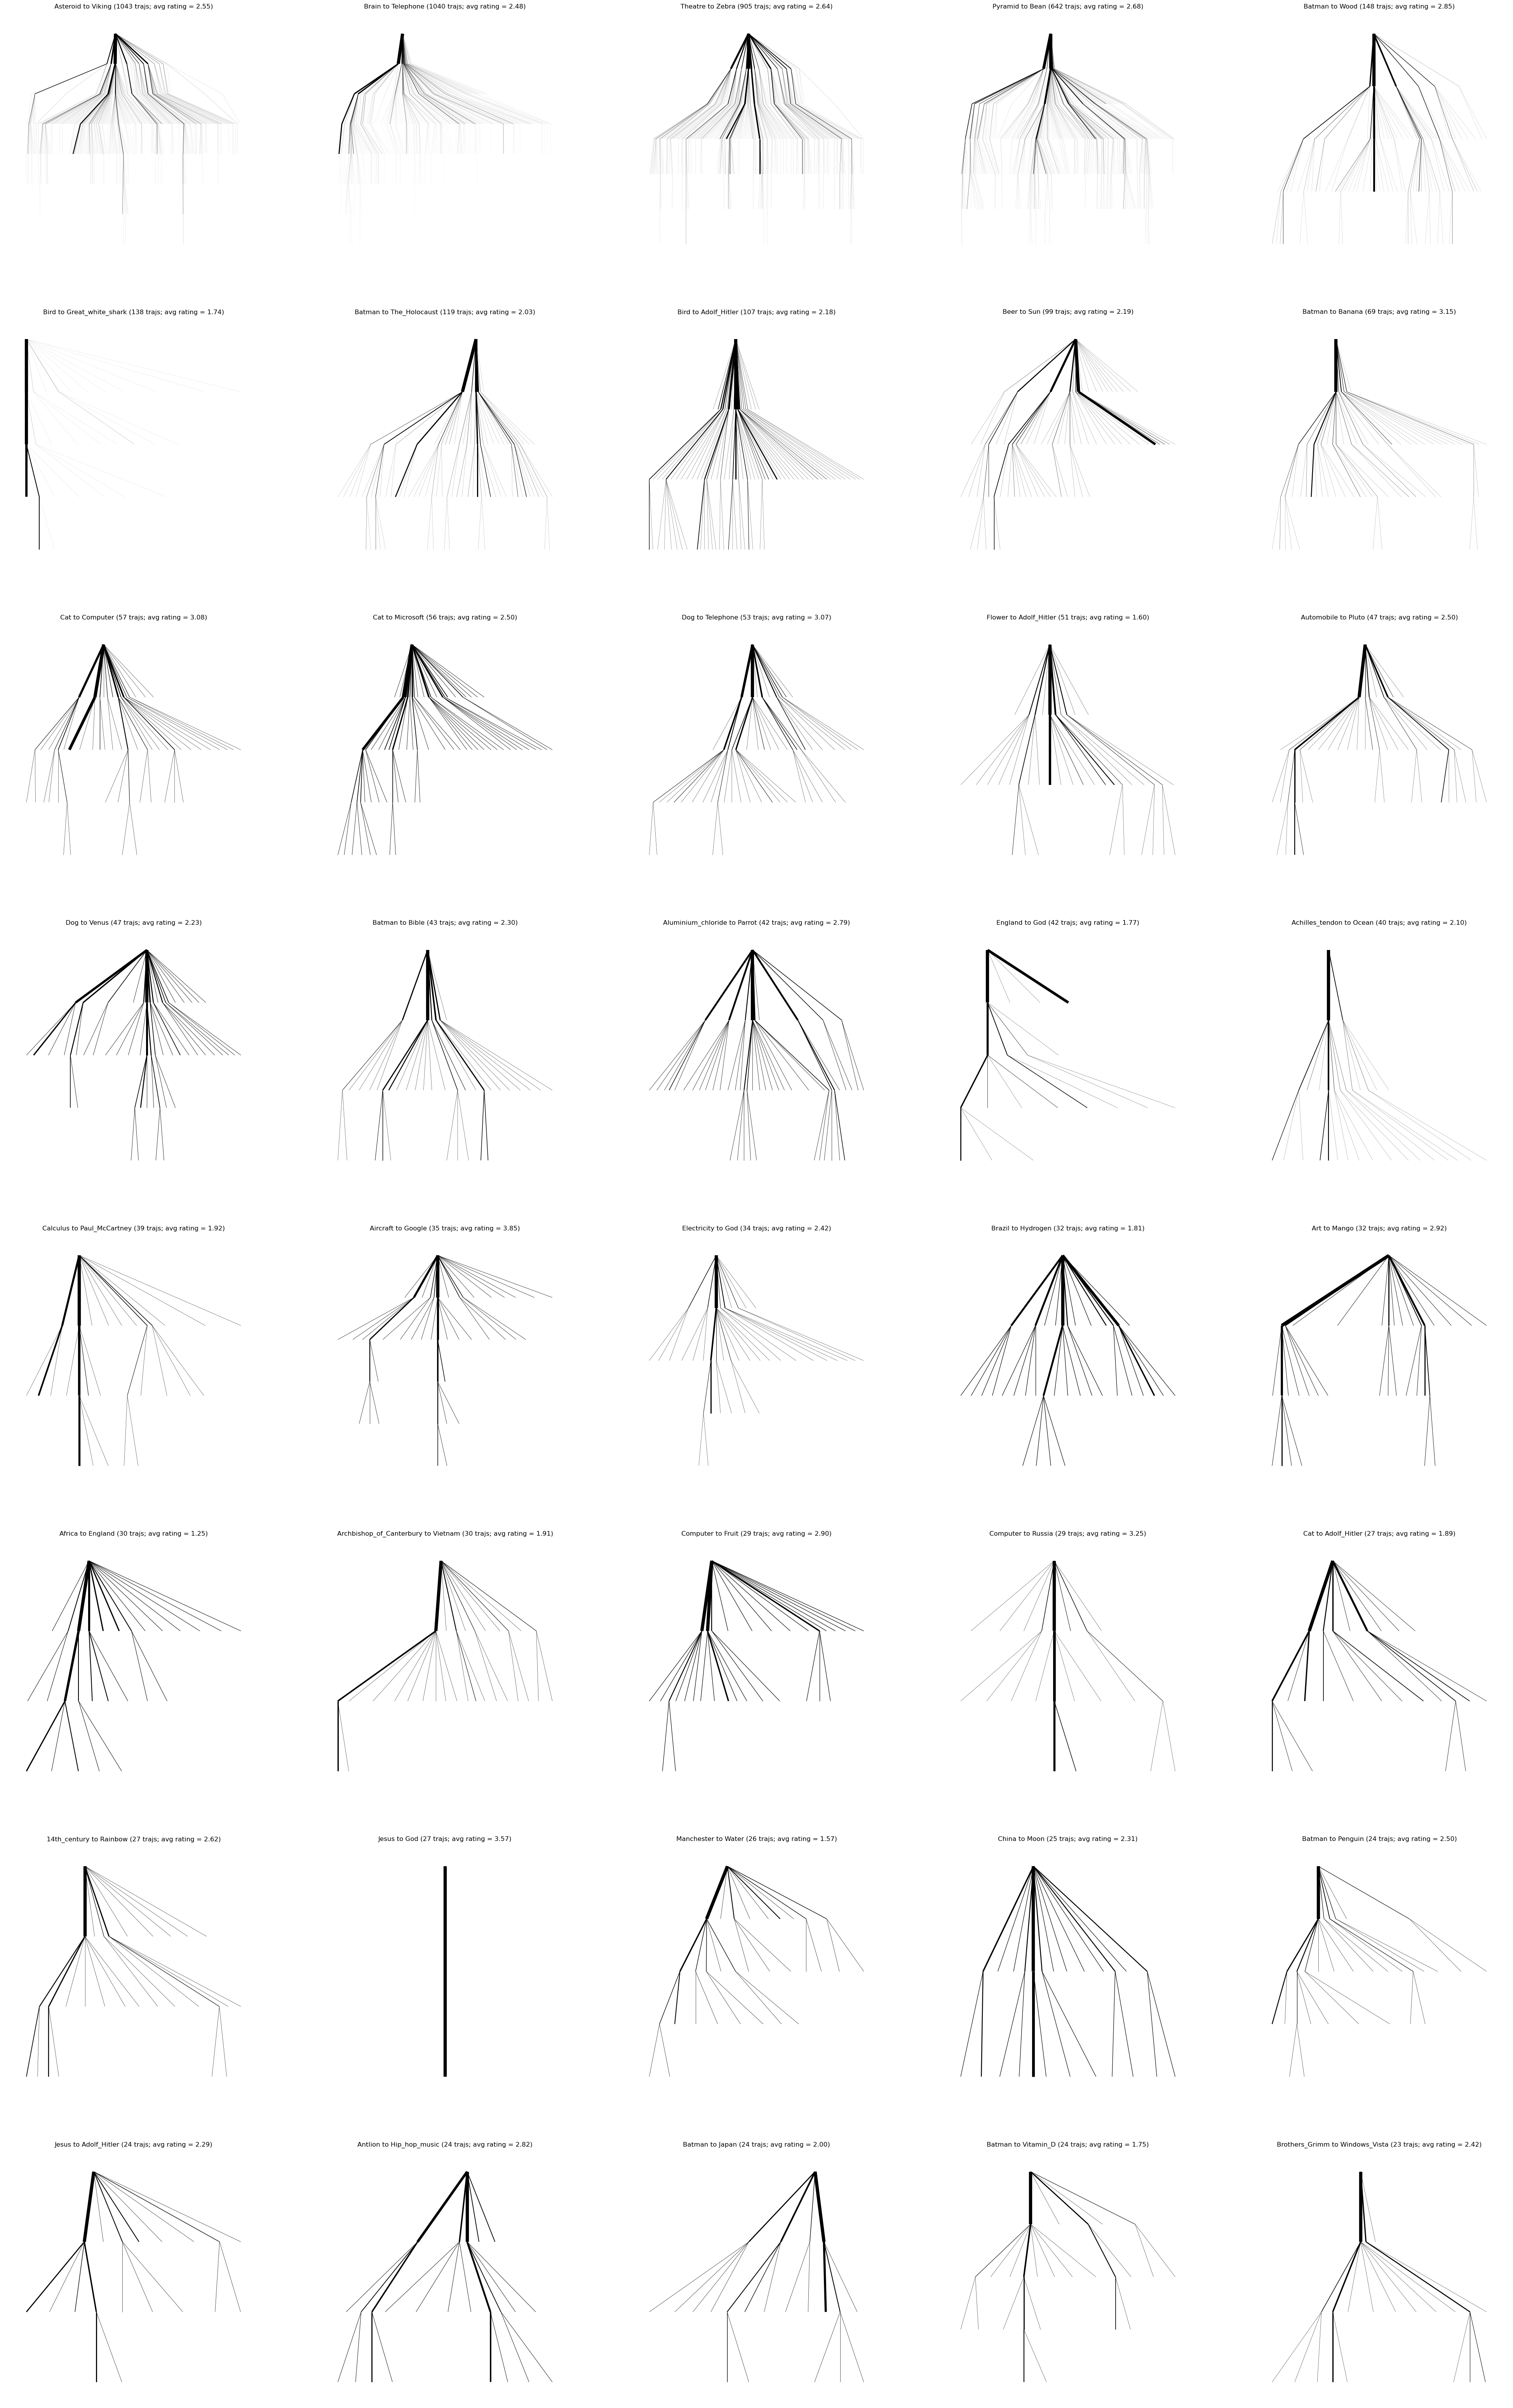

In [80]:
paths_to_plot = [path.split("_") for path in most_common_paths]

num_cols = 5
num_rows = len(paths_to_plot)//num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 10, num_rows * 10))
for i, (start_node, end_node) in enumerate(paths_to_plot):
    this_df = finished_trajs_df[(finished_trajs_df["StartAt"] == start_node) & (finished_trajs_df["EndAt"] == end_node)]
    
    avg_rating = this_df["avg_rating"].iloc[0]
    trajs = [x for x in this_df["traj"]] #random.sample(generate_trajs_from_df(this_df), min(67, len(generate_trajs_from_df(this_df))))
    
    G = generate_flow_tree_from_trajs(trajs)
    plot_flow_tree(G, f"{index_to_article[start_node]} to {index_to_article[end_node]} ({len(trajs)} trajs; avg rating = {avg_rating:.2f})", axes[i//num_cols][i%num_cols], just_edges=True)

plt.savefig("figures/wikispeedia/most_common_wikispeedia.png")
plt.show()